Se carga el dataset mushroom.csv
Se enseñan valores básicos del mismo.

In [1]:
## PASO 1: COMPROBAR QUÉ HAY QUE LIMPIAR
import pandas as pd

# Cargamos el dataset
df = pd.read_csv('mushroom.csv')

# --- PREGUNTA 1: ¿Qué aspecto tienen los datos? ---
print("=== PRIMERAS FILAS ===")
print(df.head())

# --- PREGUNTA 2: ¿Cuántas filas y columnas tenemos? ---
print("\n=== TAMAÑO DEL DATASET ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# --- PREGUNTA 3: ¿Hay datos que faltan? ---
print("\n=== DATOS QUE FALTAN POR COLUMNA ===")
print(df.isnull().sum())

# --- PREGUNTA 4: ¿Están equilibradas las clases? ---
print("\n=== ¿CUÁNTOS SETAS VENENOSAS VS NO VENENOSAS? ===")
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True).round(2))  # en porcentaje

# --- PREGUNTA 5: ¿Qué tipo de dato tiene cada columna? ---
print("\n=== TIPOS DE COLUMNAS ===")
print(df.dtypes)

=== PRIMERAS FILAS ===
  class cap_shape cap_surface cap_color bruises odor gill_attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill_spacing gill_size gill_color  ... stalk_surface_below_ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk_color_above_ring stalk_color_below_ring veil_type veil_color  \
0                      w                      w         p

Limpieza de datos y one-hot encoding.
Limpieza:
- Se pone en la categoría "stalk_root" como 'unknown'
- Se convierte nuestro objetivo de la columna "class" como 1 (comestible) o 0 (venenosa)
- Se elimina la columna "veil_type" ya que todas las filas tienen el mismo valor en esa columna.
One-hot encoding:
- Se hacen nuevas columnas para las cosas columnas que pueden tener varios valores
- Se las rellena con True o False
- Se convierten las variables en 1 y 0

In [2]:
## PASO 2: LIMPIEZA Y ENCODING

# --- 1. TRATAMIENTO DE VALORES FALTANTES ---
# 'stalk_root' tiene ~2480 NaN (originalmente '?').
# Decisión: tratamos el NaN como una categoría más ("desconocido") en vez de eliminar filas
# o imputar. Así no perdemos casi un tercio del dataset.
df['stalk_root'] = df['stalk_root'].fillna('unknown')

# --- 2. ENCODING DEL TARGET ---
# class: e=edible (comestible) -> 0, p=poisonous (venenoso) -> 1
df['class'] = df['class'].map({'e': 0, 'p': 1})

# --- 3. ELIMINAR COLUMNAS QUE NO APORTAN ---
# 'veil_type' tiene un único valor ('p') en TODO el dataset -> varianza 0, inútil
if df['veil_type'].nunique() == 1:
    df = df.drop(columns=['veil_type'])
    print("Eliminada 'veil_type' (un solo valor distinto)")

# --- 4. ONE-HOT ENCODING ---
# Todas las features restantes son categóricas nominales (letras sin orden).
# No hay ordinales claras ni binarias naturales, así que one-hot a todas.
# se guarda todas las columnas menos si es la columna 'class' (comestible / venenosa)
columnas_categoricas = [c for c in df.columns if c != 'class']
# crea nuevas columnas para poder hacer True y False en todas
# Ejemplo(columna 'cap_shape' con posibles valores b, c y x)
# Crea 3 columnas que son cap_shape_b , cap_shape_c y cap_shape_x
# Se ponen True y False donde proceda
df = pd.get_dummies(df, columns=columnas_categoricas)

# --- 5. CONVERTIR BOOL A INT ---
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

# Comprobamos que todo ha salido bien
print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())
print("\nTipos únicos:", df.dtypes.unique())


Eliminada 'veil_type' (un solo valor distinto)
Forma del dataset: (8124, 117)

Primeras filas:
   class  cap_shape_b  cap_shape_c  cap_shape_f  cap_shape_k  cap_shape_s  \
0      1            0            0            0            0            0   
1      0            0            0            0            0            0   
2      0            1            0            0            0            0   
3      1            0            0            0            0            0   
4      0            0            0            0            0            0   

   cap_shape_x  cap_surface_f  cap_surface_g  cap_surface_s  ...  \
0            1              0              0              1  ...   
1            1              0              0              1  ...   
2            0              0              0              1  ...   
3            1              0              0              0  ...   
4            1              0              0              1  ...   

   population_s  population_v  po

División de tratamiento y test:
Se separa la columna a predecir (comestible o venenosa) como Y
Todo el resto de características de las setas como X

Se separan un 80% de datos a entrenar y un 20% para probar el entrenamiento
stratify() obliga a que ese 80% tenga la misma proporción de comestibles/venenosas que el 20%

In [3]:
## PASO 3: SEPARACION EN PARAMETROS DE PREDICCION Y PARAMETROS A PREDECIR, ADEMAS DE DATOS DE ENTRENAMIENTO Y DATOS DE TEST

from sklearn.model_selection import train_test_split

# X = Tabla - Columna a predecir
# Y = Columna a predecir
X = df.drop(columns=['class'])
y = df['class']

# Dividimos en train y test
# stratify=y mantiene la proporción 60/40 en ambas partes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Filas para entrenar: {len(X_train)}")
print(f"Filas para test: {len(X_test)}")

Filas para entrenar: 6499
Filas para test: 1625


Escalado y selección de características:
- Se escalan los datos, se pone que la media sea el 0 y la desviación estándar sea 1(de normal)
- Se hace que X_train siga dicha varianza, basados en el entrenamiento
- Se hace que X_test siga la varianza del entrenamiento

In [4]:
## PASO 4: ESCALAMOS PARAMETROS

from sklearn.preprocessing import StandardScaler

# El scaler analiza las columnas a escalar y transforma los datos a la escala creada
scaler = StandardScaler()

# El scaler aprende la escala SOLO con train
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Al test solo aplicamos, no aprendemos
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(X_train.describe().round(2))

       cap_shape_b  cap_shape_c  cap_shape_f  cap_shape_k  cap_shape_s  \
count      6499.00      6499.00      6499.00      6499.00      6499.00   
mean         -0.00         0.00         0.00        -0.00        -0.00   
std           1.00         1.00         1.00         1.00         1.00   
min          -0.24        -0.02        -0.80        -0.33        -0.06   
25%          -0.24        -0.02        -0.80        -0.33        -0.06   
50%          -0.24        -0.02        -0.80        -0.33        -0.06   
75%          -0.24        -0.02         1.26        -0.33        -0.06   
max           4.12        40.30         1.26         2.99        15.48   

       cap_shape_x  cap_surface_f  cap_surface_g  cap_surface_s  \
count      6499.00        6499.00        6499.00        6499.00   
mean         -0.00           0.00           0.00          -0.00   
std           1.00           1.00           1.00           1.00   
min          -0.91          -0.64          -0.02          -0.68  

Eliminación de características:
- Se pueden eliminar características que pensamos que no nos dicen nada

In [5]:
## PASO 5.1: ELIMINAMOS FEATURES (todas sus columnas one-hot)

# Lista de FEATURES a eliminar (no columnas individuales).
# Al descomentar una, se borran todas las columnas tipo 'feature_*' relacionadas.
features_a_eliminar = [
    # 'cap_shape',
    # 'cap_surface',
    # 'cap_color',
    # 'bruises',
     'odor',
    # 'gill_attachment',
    # 'gill_spacing',
    # 'gill_size',
    # 'gill_color',
    # 'stalk_shape',
    # 'stalk_root',
    # 'stalk_surface_above_ring',
    # 'stalk_surface_below_ring',
    # 'stalk_color_above_ring',
    # 'stalk_color_below_ring',
    # 'veil_color',
    # 'ring_number',
    # 'ring_type',
    # 'spore_print_color',
    # 'population',
    # 'habitat',
]

# Convertimos los prefijos a la lista real de columnas a borrar
# Como antes hemos convertido odor a varias columnas. Por ejemplo: odor_p o odor_a
# Pues al borrar tienes que borrar todas las que empiezan por dicho prefijo
columnas_a_eliminar = [
    col for col in X_train.columns
    if any(col.startswith(f + '_') for f in features_a_eliminar)
]

# Aplicamos la eliminación
X_train_final = X_train.drop(columns=columnas_a_eliminar)
X_test_final = X_test.drop(columns=columnas_a_eliminar)

# La columnas_a_eliminar son las "hijas" que tenía la principal. Por ejemplo odor_p o odor_a
print(f"Columnas eliminadas: {len(columnas_a_eliminar)}")
print(f"Features restantes: {X_train_final.shape[1]}")


Columnas eliminadas: 9
Features restantes: 107


In [6]:
## PASO 6: SVM SIMPLE (KERNEL LINEAL)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear y entrenar una SVM simple
svm_simple = SVC(kernel='linear', C=1.0, random_state=13)

svm_simple.fit(X_train_final, y_train)

# Predicciones
y_pred_svm_simple = svm_simple.predict(X_test_final)

# Accuracy
accuracy_svm_simple = accuracy_score(y_test, y_pred_svm_simple)
print(f"\nSVM lineal Accuracy: {accuracy_svm_simple * 100:.2f}%")

# Métricas
print("\nClassification Report (SVM lineal):\n")
print(classification_report(y_test, y_pred_svm_simple))

print("\nMatriz de Confusión (SVM lineal):\n")
print(confusion_matrix(y_test, y_pred_svm_simple))


SVM lineal Accuracy: 100.00%

Classification Report (SVM lineal):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


Matriz de Confusión (SVM lineal):

[[842   0]
 [  0 783]]


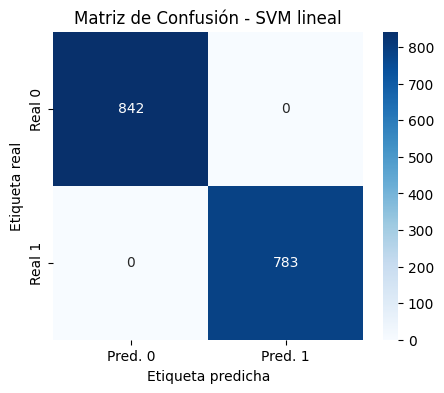

In [7]:
## PASO 7: VISUALIZACIÓN DE MÉTRICAS (Matriz de Confusión y Curva ROC)

import matplotlib.pyplot as plt
import seaborn as sns

cm_svm_simple = confusion_matrix(y_test, y_pred_svm_simple)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svm_simple,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred. 0', 'Pred. 1'],
    yticklabels=['Real 0', 'Real 1']
)
plt.title("Matriz de Confusión - SVM lineal")
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.show()